In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba.cuda import jit as cuda_jit
import math

import few

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum 


from few.utils.ylm import GetYlms

from few import get_file_manager

from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux

from few.utils.geodesic import get_fundamental_frequencies

from few.utils.constants import YRSID_SI

import os
import sys

# Change to the desired directory
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

# Add it to Python path
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

import GWfuncs
import loglikebasic
import modeselector
import parismc
# import gc
import pickle
import cupy as cp

# tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")



In [2]:
# GPU configuration 
use_gpu = True
force_backend = "cuda12x"  
dt = 10     # Time step
T = 0.25     # Total time

print('Initializing waveform generator...')
# keyword arguments for inspiral generator 
inspiral_kwargs={
        "func": 'KerrEccEqFlux',
        "DENSE_STEPPING": 0, #change to 1/True for uniform sampling
        "include_minus_m": False, 
}

# keyword arguments for inspiral generator 
amplitude_kwargs = {
    "force_backend": "cuda12x" # Force GPU
}

# keyword arguments for Ylm generator (GetYlms)
Ylm_kwargs = {
    "force_backend": "cuda12x",  # Force GPU
    # "assume_positive_m": True  # if we assume positive m, it will generate negative m for all m>0
}

# keyword arguments for summation generator (InterpolatedModeSum)
sum_kwargs_comb = {
    "force_backend": "cuda12x",  # Force GPU
    "pad_output": True,
}

sum_kwargs_sep = {
    "force_backend": "cuda12x",  # Force GPU
    "pad_output": True,
    "separate_modes": True,
}

print("Creating GenerateEMRIWaveform class...")
# Kerr eccentric flux
waveform_gen_comb = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_comb,
    use_gpu=use_gpu
)

# Kerr eccentric flux
waveform_gen_sep = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_sep,
    use_gpu=use_gpu
)


print('Done initializing waveform generator.')

Initializing waveform generator...
Creating GenerateEMRIWaveform class...
Done initializing waveform generator.


In [3]:
gwf = GWfuncs.GravWaveAnalysis(T, dt)

In [4]:
# Source parameters
m1 = 1e6
m2 = 3e1
a = 0.7
p0 = 7.5
e0 = 0.4 
xI0 = 1.0
dist = 2 # Gpc
# Polar and azimuthal angles .. detector frame
# S = Solar system barycenter
# K = spin angular momentum of the MBH
qS = 0.5 
phiS = 1 
qK = 1 #fixed
phiK = phiS + np.pi/3
# Phases
Phi_phi0 = 0.4
Phi_theta0 = 0.0 # equatorial
Phi_r0 = 0.5


In [5]:
params_star = (m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0)

In [25]:
# NOTE: for now, M_init = M_mode (basically just selecting top 5 modes based on power, no combining)
loglike_obj = loglikebasic.LogLike(params_star, waveform_gen_comb, gwf, M_init=5, verbose=True, waveform_gen_sep=waveform_gen_sep, noise_weighted=True)

Generating modes at initialization...
Initial mode selected: (2, -2, -1) with power 9.974322381817613e+40
Considering mode 1 / 5 : (2, -2, 0) with power 6.642690878968553e+40
 - Overlap with selected mode 0: 1.3756183678931472e-05
Considering mode 2 / 5 : (2, -2, 1) with power 1.6105119343067213e+40
 - Overlap with selected mode 0: 0.0
 - Overlap with selected mode 1: 4.104610127803452e-06
Considering mode 3 / 5 : (3, -3, -1) with power 1.037050715512486e+40
 - Overlap with selected mode 0: 1.0738379849810785e-05
 - Overlap with selected mode 1: 2.501856214691895e-06
 - Overlap with selected mode 2: 0.0
Considering mode 4 / 5 : (3, -3, 1) with power 8.643527711562299e+39
 - Overlap with selected mode 0: 4.211376084638782e-06
 - Overlap with selected mode 1: 1.0763006452275218e-06
 - Overlap with selected mode 2: 2.0388460867456177e-06
 - Overlap with selected mode 3: 0.0
Final selected labels: [[(2, -2, -1)], [(2, -2, 0)], [(2, -2, 1)], [(3, -3, -1)], [(3, -3, 1)]]
Number of mode group

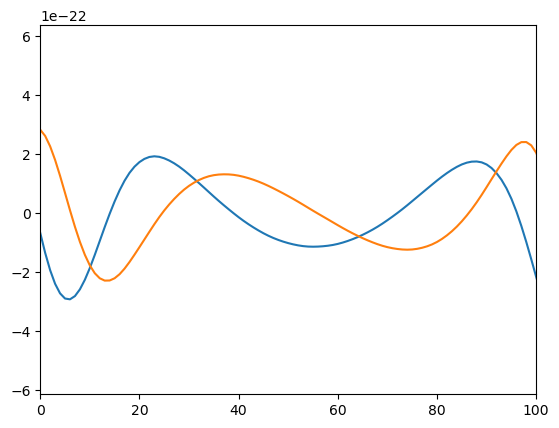

In [26]:
data = loglike_obj.signal
plt.plot(data.get().real)
plt.plot(data.get().imag)
plt.xlim(0, 100)
plt.show()

In [27]:
data.shape

(788954,)

In [28]:
gwf.rhostat(data)

array(26.85986158)

In [29]:
def log_density(params):
    params = np.asarray(params)

    n_samples = params.shape[0] 
    log_likes = np.zeros(n_samples)


    for i in range(n_samples):
        logm1, logm2, a, p0, e0, dist, cosqS, phiS, Phi_phi0, Phi_r0 = params[i]
        m1 = 10**logm1
        m2 = 10**logm2
        qS = np.arccos(cosqS)
        phiK = phiS + np.pi/3

        loglike = loglike_obj(np.array([m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]))
        log_likes[i] = loglike
        
    return log_likes

# def loglike(theta_batch):
#     if theta_batch.ndim == 1:
#         # Single parameter set
#         return loglike_obj(theta_batch)

#     # Batch evaluation
#     results = []
#     for i in range(theta_batch.shape[0]):
#         result = loglike_obj(theta_batch[i])
#         results.append(result)
#     return np.array(results)

In [30]:
def prior_transform(u):
    logm1lim = [5.9999546549e+00, 6.0000453451e+00]
    logm2lim = [1.4770940442e+00, 1.4771484652e+00]
    alim = [6.9991943608e-01, 7.0008056392e-01]
    p0lim = [7.4995568044e+00, 7.5004431956e+00]
    e0lim = [3.9997901137e-01, 4.0002098863e-01]
    distlim = [1.9727323083e+00, 2.0272676917e+00]
    cosqSlim = [8.6479203952e-01, 8.9037308426e-01]
    phiSlim = [9.7750458220e-01, 1.0224954178e+00]
    Phiphilim = [3.8232596200e-01, 4.1767403800e-01]
    Phirlim = [4.9151222865e-01, 5.0848777135e-01]

    transformed = np.zeros_like(u)

    # Uniform in log for masses

    # m1
    transformed[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]

    # m2
    transformed[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]

    # Linear in others 

    # a
    transformed[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]

    # p0
    transformed[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0] 

    # e0
    transformed[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]

    # dist 
    transformed[:, 5] = (distlim[1] - distlim[0]) * u[:, 5] + distlim[0]

    # Uniform in cosqS 

    # qS
    transformed[:, 6] = (cosqSlim[1] - cosqSlim[0]) * u[:, 6] + cosqSlim[0]

    # phiS
    transformed[:, 7] = (phiSlim[1] - phiSlim[0]) * u[:, 7] + phiSlim[0]

    # Phi_phi0
    transformed[:, 8] = (Phiphilim[1] - Phiphilim[0]) * u[:, 8] + Phiphilim[0]

    # Phi_r0
    transformed[:, 9] = (Phirlim[1] - Phirlim[0]) * u[:, 9] + Phirlim[0]

    
    return transformed

In [31]:
loglike_obj((m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0))

Waveform amplitudes:
  Mode 0: max(|h|) = 1.3056496247566425e-22, <hf|hf> = 14.484506437678151, rho = 3.8058516047894133
  Mode 1: max(|h|) = 1.7784069603572985e-22, <hf|hf> = 108.05203920063416, rho = 10.394808281090814
  Mode 2: max(|h|) = 1.7630616204278926e-22, <hf|hf> = 272.73807476733845, rho = 16.514783521661386
  Mode 3: max(|h|) = 4.7050492497426216e-23, <hf|hf> = 12.374713598381064, rho = 3.5177711122784925
  Mode 4: max(|h|) = 5.670310094610739e-23, <hf|hf> = 17.56797283934149, rho = 4.191416567145467
Individual rho values: [ 3.8058516  10.39480828 16.51478352  3.51777111  4.19141657]
Max rho: 16.514783521661386, Min rho: 3.5177711122784925
Dominant mode rho (first): 3.8058516047894133
Actually dominant mode index: 2
Actually dominant mode rho: 16.514783521661386
Mode 0 rho: 3.8058516047894133
Xdotrho: (425.5655156354977+0j)
Using actually dominant mode 2 for rho_dom_M: 16.514783521661386
rho_dom_M: 16.514783521661386, rho_tot: 20.620797919658038, beta: 0.036782136328907006


20.624665279988896

In [32]:
X = gwf.Xstat(data, data)
X

array(26.85986158)

In [ ]:
import traceback
def search_example(n_samples=10):
    print(f"Running parameter space search with {n_samples} samples...")
    
    # logm1_range = (5.9999546549e+00, 6.0000453451e+00)
    # logm2_range = (1.4770940442e+00, 1.4771484652e+00)
    # a_range = (6.9991943608e-01, 7.0008056392e-01)
    # p0_range = (7.4995568044e+00, 7.5004431956e+00)
    # e0_range = (3.9997901137e-01, 4.0002098863e-01)
    # dist_range = (1.9727323083e+00, 2.0272676917e+00)
    # cosqS_range = (8.6479203952e-01, 8.9037308426e-01)
    # phiS_range = (9.7750458220e-01, 1.0224954178e+00)
    # Phiphi_range = (3.8232596200e-01, 4.1767403800e-01)
    # Phir_range = (4.9151222865e-01, 5.0848777135e-01)
    
    logm1_range = (5.9999848849504e+00, 6.0000151150496e+00)
    logm2_range = (1.4771121845576e+00, 1.4771303248817e+00)
    a_range = (6.9997314536e-01, 7.0002685464e-01)
    p0_range = (7.4998522681e+00, 7.5001477319e+00)
    e0_range = (3.9999300379e-01, 4.0000699621e-01)
    dist_range = (1.9909107695e+00, 2.0090892305e+00)
    cosqS_range = (8.7321891144e-01, 8.8194610234e-01)
    phiS_range = (9.9250152740e-01, 1.0074984726e+00)
    Phiphi_range = (3.9410865400e-01, 4.0589134600e-01)
    Phir_range = (4.9717074288e-01, 5.0282925712e-01)
    # Seed for reproducibility
    np.random.seed(7)  
    
    for i in range(n_samples):
        # Sample all uniformly
        params = np.array([
            np.random.uniform(*logm1_range),
            np.random.uniform(*logm2_range), 
            np.random.uniform(*a_range),
            np.random.uniform(*p0_range),
            np.random.uniform(*e0_range),
            xI0,
            np.random.uniform(*dist_range),
            np.random.uniform(*cosqS_range),
            np.random.uniform(*phiS_range),
            qK,
            np.random.uniform(*phiS_range) + np.pi/3,
            np.random.uniform(*Phiphi_range),
            Phi_theta0,
            np.random.uniform(*Phir_range)
        ])
        
        try:
            # Evaluate likelihood
            print(f" === Parameters for sample {i+1}: {params} ===")
            f_stat = loglike_obj(params)
            print(f"Sample {i+1}/{n_samples}: f_stat = {f_stat}")
                
        except Exception as e:
            print(f"Error in evaluation {i+1}: {e}")
            print(f"Full traceback: {traceback.format_exc()}")
            continue


In [ ]:
loglike_obj((m1+1e-10, m2+1e-10, a+1e-2, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0))

In [ ]:
%%time
search_example(n_samples=10)

In [ ]:
print('Done setting up log-likelihood and prior.')
print('Setting up ParisMC sampler...')
config = parismc.SamplerConfig(
    merge_confidence=0.9,          # Coverage prob → Mahalanobis merge radius R_m (higher is more permissive)
    alpha=10000,                    # Use recent samples for weighting. 
    trail_size=int(1e3),          # Maximum trials per iteration
    boundary_limiting=True,        # Enable boundary constraints
    use_beta=True,                # Use beta correction for boundaries
    integral_num=int(1e5),        # MC samples for beta estimation
    gamma=500,                    # Covariance update frequency
    exclude_scale_z=np.inf,       # No exclusion based on weights
    use_pool=False,               # Set to True for multiprocessing
    n_pool=4                      # Number of processes (if use_pool=True)
)

In [ ]:
print('Done setting up ParisMC sampler.')
print('Setting up initial covariance matrix...')
# Change to the desired directory
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/sampling_test')

# Add it to Python path
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/sampling_test')

with open('cov_matrix_new.pkl', 'rb') as f:
    cov_matrix = pickle.load(f)

ndim = 10
n_seed = 1

init_cov_list = [cov_matrix for _ in range(n_seed)]

print('Done setting up initial covariance matrix.')

In [ ]:
print('Initializing sampler...')
sampler = parismc.Sampler(
    ndim=ndim, 
    n_seed=n_seed,
    log_density_func=log_density,
    init_cov_list=init_cov_list,
    prior_transform=prior_transform,
    config=config
)
print('Done initializing sampler.')

In [ ]:
print('Preparing LHS samples...')
sampler.prepare_lhs_samples(lhs_num=int(100), batch_size=10)
print('Done preparing LHS samples.')

In [ ]:
print('Running sampling...')
sampler.run_sampling(
    num_iterations=int(1e5), 
    savepath='./paris_ffunc_basic/',
    print_iter=100 # Print progress every n iterations
)
print('Done running sampling.')